# DETEKSI TRANSAKSI PENIPUAN (FRAUD DETECTION)

## IMPORT LIBRARY

In [ ]:
# Manipulasi data
import pandas as pd  # Untuk manipulasi dan analisis data
import numpy as np  # Untuk operasi numerik dan array

# Visualisasi
import matplotlib.pyplot as plt  # Untuk membuat visualisasi dasar seperti plot, bar, dll
import seaborn as sns  # Untuk visualisasi statistik yang lebih menarik

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Untuk encoding label dan standarisasi

# Split data
from sklearn.model_selection import train_test_split  # Untuk membagi data menjadi data latih dan data uji

# Modeling
from sklearn.ensemble import RandomForestClassifier  # Untuk model Random Forest

# Evaluasi model
from sklearn.metrics import accuracy_score  # Untuk menghitung akurasi prediksi
from sklearn.metrics import confusion_matrix, classification_report  # Untuk confusion matrix dan laporan klasifikasi

# Imbalanced data (opsional jika data tidak seimbang)
from imblearn.over_sampling import SMOTE  # Untuk penyeimbangan data menggunakan SMOTE

## LOAD DATASET

In [ ]:
# Menghubungkan Google Colab ke Goole Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/datasets/fraudulent_ecommerce_dataset/Fraudulent_E-Commerce_Transaction_Data.csv')  # Membaca data CSV ke dalam DataFrame
df.head()  # Menampilkan 5 baris pertama sebagai preview dari dataset

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,8ca9f102-02a4-4207-ab63-484e83a1bdf0,42.32,2024-03-24 23:42:43,PayPal,electronics,1,40,East Jameshaven,desktop,110.87.246.85,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,0,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,4d158416-caae-4b09-bd5b-15235deb9129,301.34,2024-01-22 00:53:31,credit card,electronics,3,35,Kingstad,tablet,14.73.104.153,"5230 Stephanie Forge\nCollinsbury, PR 81853","5230 Stephanie Forge\nCollinsbury, PR 81853",0,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,ccae47b8-75c7-4f5a-aa9e-957deced2137,340.32,2024-01-22 08:06:03,debit card,toys & games,5,29,North Ryan,desktop,67.58.94.93,"195 Cole Oval\nPort Larry, IA 58422","4772 David Stravenue Apt. 447\nVelasquezside, ...",0,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,b04960c0-aeee-4907-b1cd-4819016adcef,95.77,2024-01-16 20:34:53,credit card,electronics,5,45,Kaylaville,mobile,202.122.126.216,"7609 Cynthia Square\nWest Brenda, NV 23016","7609 Cynthia Square\nWest Brenda, NV 23016",0,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,de9d6351-b3a7-4bc7-9a55-8f013eb66928,77.45,2024-01-16 15:47:23,credit card,clothing,5,42,North Edwardborough,desktop,96.77.232.76,"2494 Robert Ramp Suite 313\nRobinsonport, AS 5...","2494 Robert Ramp Suite 313\nRobinsonport, AS 5...",0,116,15


In [ ]:
print("Dimensi dataset:", df.shape)  # Menampilkan jumlah baris dan kolom
df.info()  # Menampilkan informasi kolom, tipe data, dan jumlah non-null (kolom yang tidak memiliki nilai kosong)

Dimensi dataset: (23634, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      23634 non-null  object 
 1   Customer ID         23634 non-null  object 
 2   Transaction Amount  23634 non-null  float64
 3   Transaction Date    23634 non-null  object 
 4   Payment Method      23634 non-null  object 
 5   Product Category    23634 non-null  object 
 6   Quantity            23634 non-null  int64  
 7   Customer Age        23634 non-null  int64  
 8   Customer Location   23634 non-null  object 
 9   Device Used         23634 non-null  object 
 10  IP Address          23634 non-null  object 
 11  Shipping Address    23634 non-null  object 
 12  Billing Address     23634 non-null  object 
 13  Is Fraudulent       23634 non-null  int64  
 14  Account Age Days    23634 non-null  int64  
 15  Transaction Hour    2363

## DATA PRE-PROCESSING

Pada kode dibawah ini, kolom `Transaction Date` diubah ke format datetime. Selanjutnya, diekstrak beberapa fitur waktu seperti tanggal transaksi `(Transaction Day)`, hari dalam minggu `(Transaction DOW)`, dan bulan transaksi `(Transaction Month)` yang dapat berguna dalam analisis pola transaksi atau sebagai fitur input untuk model machine learning

In [ ]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])  # Mengubah tipe data menjadi datetime
df['Transaction Day'] = df["Transaction Date"].dt.day  # Mengambil tanggal (1–31) dari kolom tanggal
df["Transaction DOW"] = df["Transaction Date"].dt.dayofweek  # Mengambil indeks hari (0 = Senin, 6 = Minggu)
df["Transaction Month"] = df["Transaction Date"].dt.month  # Mengambil bulan (1–12) dari kolom tanggal

In [ ]:
# Menghapus kolom yang tidak diperlukan dari dataset
df.drop(columns=["Transaction ID", "Customer ID", "Customer Location",
                  "IP Address", "Transaction Date","Shipping Address","Billing Address"], inplace=True)

In [ ]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour,Transaction Day,Transaction DOW,Transaction Month
count,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000
mean,229.367099,3.000550,34.560210,0.051705,178.660531,11.266015,14.860878,2.960481,2.130532
std,282.046669,1.419663,10.009471,0.221436,107.388682,6.980659,8.994172,1.996835,0.944405
min,10.000000,1.000000,-2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,69.070000,2.000000,28.000000,0.000000,84.000000,5.000000,7.000000,1.000000,1.000000
50%,151.415000,3.000000,35.000000,0.000000,178.000000,11.000000,15.000000,3.000000,2.000000
75%,296.127500,4.000000,41.000000,0.000000,272.000000,17.000000,23.000000,5.000000,3.000000
max,9716.500000,5.000000,73.000000,1.000000,365.000000,23.000000,31.000000,6.000000,4.000000


Untuk menangani nilai pada kolom Customer Age yang bernilai -2 (yang tidak masuk akal untuk usia pelanggan), dilakukan penggantian nilai tersebut dengan nilai median usia dari data yang valid (yaitu data dengan nilai usia lebih dari 0)

In [ ]:
# Hitung median dari nilai Customer Age yang valid
median_age = df[df['Customer Age'] > 0]['Customer Age'].median()

# Ganti semua nilai -2 dengan median
df['Customer Age'] = df['Customer Age'].replace(-2, median_age)

In [ ]:
# Mengecek jumlag missing value dari setiap kolom
df.isnull().sum()

,0
Transaction Amount,0
Payment Method,0
Product Category,0
Quantity,0
Customer Age,0
Device Used,0
Is Fraudulent,0
Account Age Days,0
Transaction Hour,0
Transaction Day,0


Tidak ada missing value

## EXPLORATORY DATA ANALYSIS (EDA) - VISUALISASI DAN ANALISIS


### Features Understanding (Visualisasi untuk memahami fitur (kolom dalam dataset)

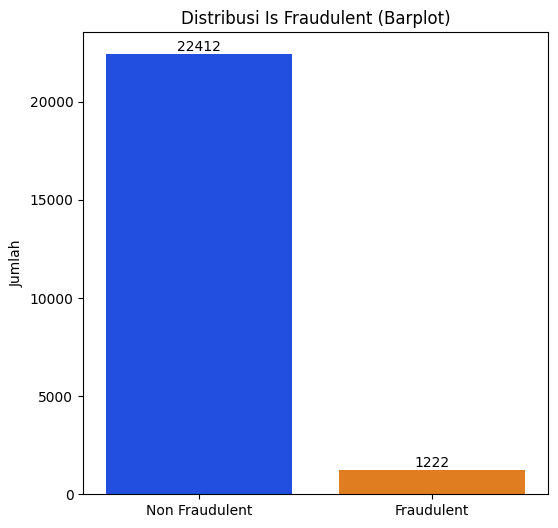

In [ ]:
plt.figure(figsize=(6, 6))  # Mengatur ukuran gambar plot menjadi 6x4 inch
ax = sns.countplot(data=df, x='Is Fraudulent', hue='Is Fraudulent', palette='bright', legend=False)  # Membuat countplot dengan warna cerah dan menjadikan 'Is Fraudulent' sebagai hue untuk menghilangkan warning
plt.xticks(ticks=[0, 1], labels=['Non Fraudulent', 'Fraudulent'])  # Mengganti label sumbu x dari angka menjadi deskriptif
plt.title('Distribusi Is Fraudulent (Barplot)')  # Memberi judul pada plot
plt.xlabel('')  # Mengosongkan label sumbu x karena sudah menggunakan label kustom di xticks
plt.ylabel('Jumlah')  # Memberi label pada sumbu y sebagai jumlah data

# Menambahkan anotasi jumlah data tepat di atas tiap bar
for p in ax.patches:  # Iterasi untuk setiap bar pada plot
    height = p.get_height()  # Mengambil tinggi bar (jumlah data)
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),  # Menempatkan teks di tengah atas bar
                ha='center', va='bottom')  # Horizontal align tengah, vertical align di bawah teks

plt.show()  # Menampilkan plot

Berdasakran visualisasi distribusi diatas:
- Non Fraudulent berjumlah `22412`
- Fraudulent berjumlag `1222`

Terlihat jelas bahwa dataset mengalami ketidakseimbangan kelas (imbalanced data) yang cukup signifikan, di mana jumlah transaksi non-fraud jauh lebih besar dibanding transaksi fraud.

Oleh karena itu, sebelum data dimasukkan ke dalam model, akan dilakukan teknik oversampling menggunakan SMOTE (Synthetic Minority Over-sampling Technique). Tujuannya adalah untuk menyeimbangkan jumlah data pada masing-masing kelas.

`Alasan kenapa data perlu diseimbangkan:`

Jika data tidak diseimbangkan, model cenderung akan "berpihak" pada kelas mayoritas (non-fraud) karena model belajar dari pola yang paling sering muncul.

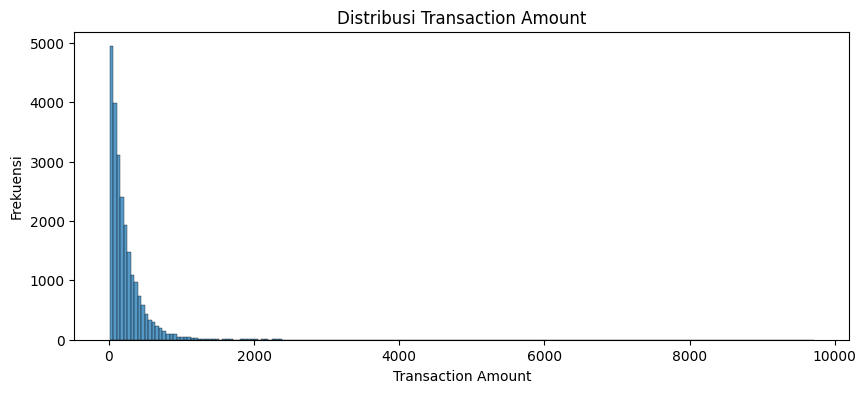

In [ ]:
plt.figure(figsize=(10, 4))  # Mengatur ukuran plot menjadi lebar 10 inch dan tinggi 4 inch
sns.histplot(df["Transaction Amount"], bins=200)  # Membuat histogram untuk kolom 'Transaction Amount' dengan 200 bin untuk detail distribusi
plt.title('Distribusi Transaction Amount')  # Memberikan judul plot
plt.xlabel('Transaction Amount')  # Label sumbu x
plt.ylabel('Frekuensi')  # Label sumbu y
plt.show()  # Menampilkan plot

Berdasarkan visualisasi Transaction Amount yang ditampilkan, berikut kesimpulan yang dapat diambil:
- Mayoritas transaksi berada pada kisaran 0 hingga 1000 satuan mata uang.
- Frekuensi transaksi menurun drastis seiring dengan meningkatnya jumlah transaksi.
- Data memiliki distribusi yang right-skewed (condong ke kanan), yang berarti sebagian besar nilai berada di sisi kecil dan hanya sedikit transaksi dengan jumlah besar.

Kesimpulan: Distribusi nilai transaksi menunjukkan bahwa sebagian besar transaksi terjadi dalam jumlah kecil (di bawah 1000), sementara transaksi dengan jumlah besar relatif jarang terjadi. Hal ini mengindikasikan bahwa perilaku transaksi didominasi oleh nominal kecil, sedangkan transaksi bernilai besar bersifat tidak umum atau hanya dilakukan oleh segelintir pihak tertentu.









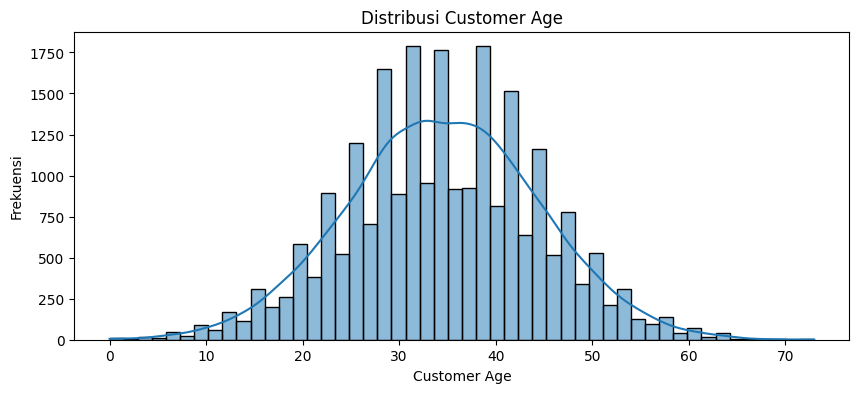

In [ ]:
plt.figure(figsize=(10, 4))  # Atur ukuran plot agar lebar dan tidak terlalu tinggi
sns.histplot(df['Customer Age'], bins=50, kde=True)  # Histogram dengan 50 bin dan garis KDE untuk melihat distribusi usia
plt.title('Distribusi Customer Age')  # Judul plot
plt.xlabel('Customer Age')  # Label sumbu x
plt.ylabel('Frekuensi')  # Label sumbu y
plt.show()  # Tampilkan plot

Dari visualisasi diatas, terlihat bahwa `Customer Age terdistribusi dengan normal`

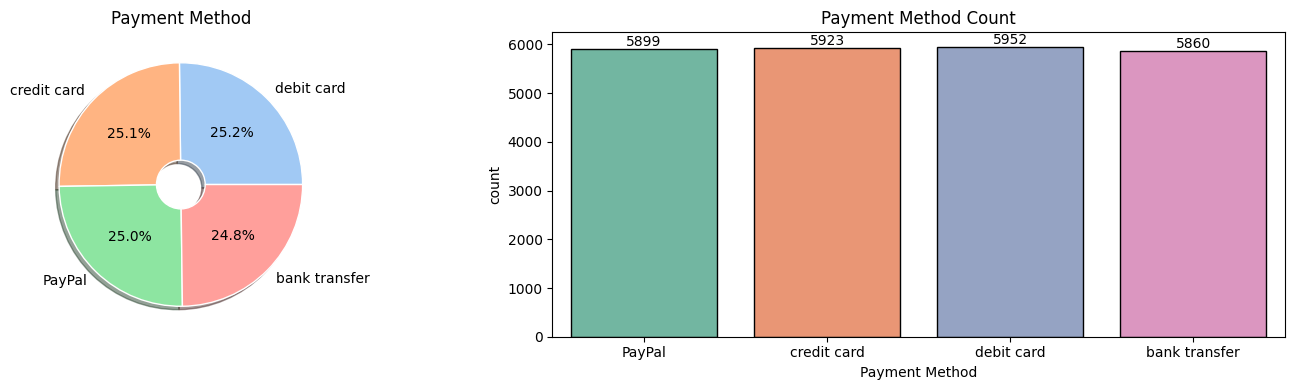

In [ ]:
payment_count = df["Payment Method"].value_counts()  # Hitung jumlah tiap metode pembayaran

plt.figure(figsize=(15, 4))  # Atur ukuran gambar

# Pie chart
plt.subplot(1, 2, 1)
sns.set_palette('pastel')  # Set palette warna pastel
colors = sns.color_palette()
plt.pie(payment_count, labels=payment_count.index, shadow=True, autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8, edgecolor="w"))  # Buat pie chart
plt.title("Payment Method")

# Bar plot tanpa future warning
plt.subplot(1, 2, 2)
# Gunakan hue=x dan matikan legend agar tidak muncul dua kali
ax = sns.countplot(data=df, x="Payment Method", hue="Payment Method", legend=False,
                   edgecolor="black", linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)  # Tambah label jumlah di atas bar
plt.title("Payment Method Count")

plt.tight_layout()  # Rapikan layout
plt.show()

Dari visualisasi diatas, terlihat bahwa `semua Payment Method terdistribusi dengan rata`

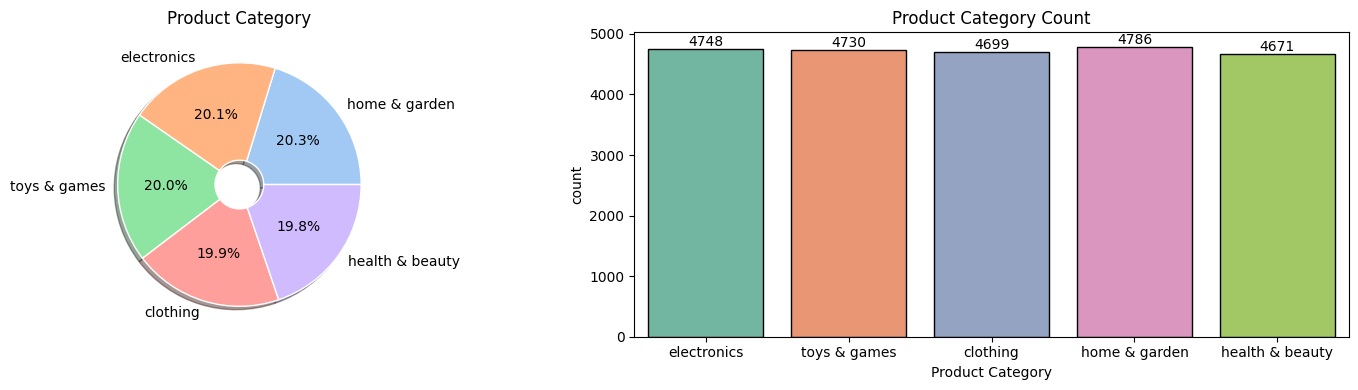

In [ ]:
category_count = df["Product Category"].value_counts()  # Hitung jumlah tiap kategori produk

plt.figure(figsize=(15, 4))  # Atur ukuran gambar

# Pie chart
plt.subplot(1, 2, 1)
sns.set_palette('pastel')  # Set palette warna pastel
colors = sns.color_palette()
plt.pie(category_count, labels=category_count.index, shadow=True, autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8, edgecolor="w"))  # Buat pie chart
plt.title("Product Category")

# Bar plot tanpa future warning
plt.subplot(1, 2, 2)
# Gunakan hue=x dan matikan legend agar tidak muncul dua kali
ax = sns.countplot(data=df, x="Product Category", hue="Product Category", legend=False,
                   edgecolor="black", linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)  # Tambah label jumlah di atas bar
plt.title("Product Category Count")

plt.tight_layout()  # Rapikan layout
plt.show()

Dari visualisasi diatas, terlihat bahwa `semua Product Category terdistribusi dengan rata`

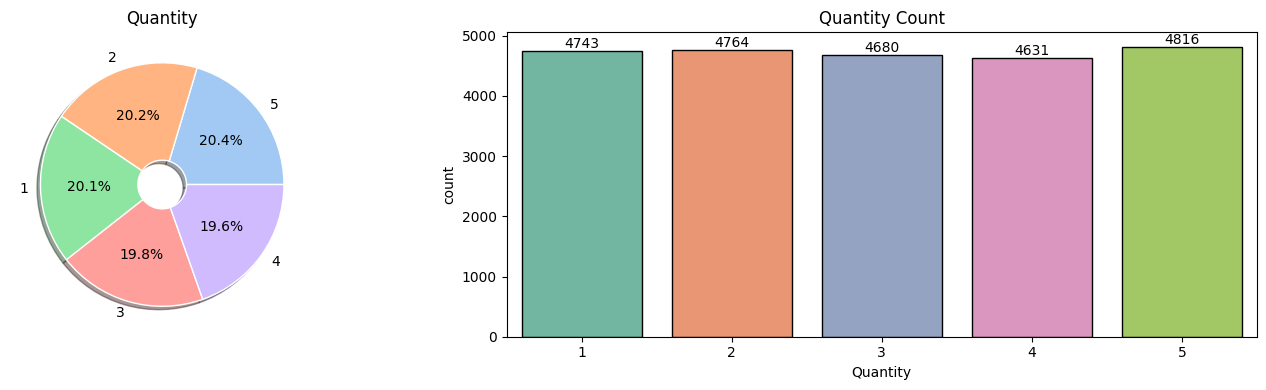

In [ ]:
quantity_count = df["Quantity"].value_counts()  # Hitung frekuensi masing-masing nilai Quantity

plt.figure(figsize=(15, 4))  # Atur ukuran figure lebar dan tidak terlalu tinggi

# Pie chart
plt.subplot(1, 2, 1)
sns.set_palette('pastel')  # Set warna palet pastel untuk pie chart
colors = sns.color_palette()
plt.pie(quantity_count, labels=quantity_count.index, shadow=True, autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8, edgecolor="w"))  # Set lebar irisan dan garis tepi putih
plt.title("Quantity")

# Bar plot tanpa future warning
plt.subplot(1, 2, 2)
# Gunakan hue=x dan matikan legend agar tidak muncul dua kali
ax = sns.countplot(data=df, x="Quantity", hue="Quantity", legend=False,
                   edgecolor="black", linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)  # Tampilkan jumlah value di atas tiap bar
plt.title("Quantity Count")

plt.tight_layout()  # Rapikan tata letak supaya plot tidak saling tumpang tindih
plt.show()  # Tampilkan kedua plot

Dari visualisasi diatas, terlihat bahwa `semua Quantity terdistribusi dengan rata`

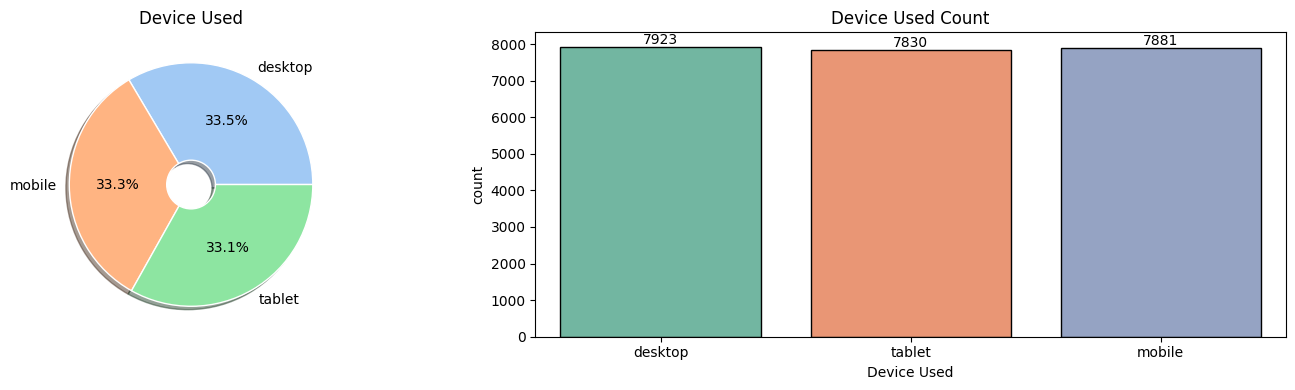

In [ ]:
device_count = df["Device Used"].value_counts()  # Hitung frekuensi masing-masing device yang digunakan

plt.figure(figsize=(15, 4))  # Atur ukuran figure lebar dan tidak terlalu tinggi

# Pie chart
plt.subplot(1, 2, 1)
sns.set_palette('pastel')  # Set warna palet pastel untuk pie chart
colors = sns.color_palette()
plt.pie(device_count, labels=device_count.index, shadow=True, autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8, edgecolor="w"))  # Set lebar irisan dan garis tepi putih
plt.title("Device Used")

# Bar plot tanpa future warning
plt.subplot(1, 2, 2)
# Gunakan hue=x dan matikan legend agar tidak muncul dua kali
ax = sns.countplot(data=df, x="Device Used", hue="Device Used", legend=False,
                   edgecolor="black", linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)  # Tampilkan jumlah value di atas tiap bar
plt.title("Device Used Count")

plt.tight_layout()  # Rapikan tata letak supaya plot tidak saling tumpang tindih
plt.show()  # Tampilkan kedua plot

Dari visualisasi diatas, terlihat bahwa `semua Device Used terdistribusi dengan rata`

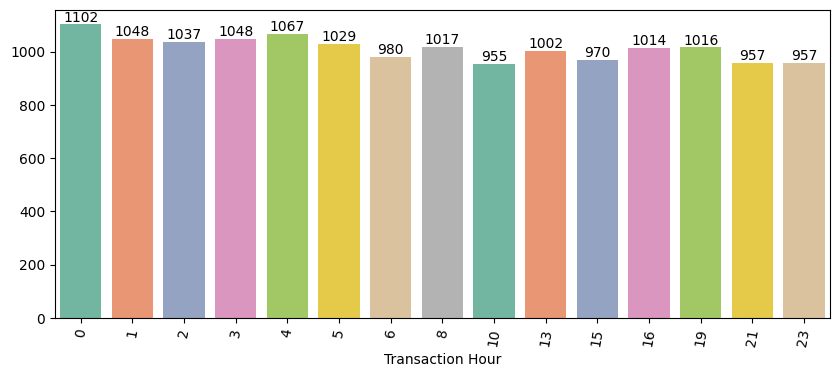

In [ ]:
hour_count = df["Transaction Hour"].value_counts().head(15)  # Hitung frekuensi jam transaksi, ambil 15 jam dengan frekuensi tertinggi

plt.figure(figsize=(10, 4))  # Atur ukuran figure lebar dan pendek
sns.set_palette('Set2')  # Set palet warna Set2 untuk barplot

# Buat barplot dengan hue=x dan matikan legend agar tidak muncul dua kali
ax = sns.barplot(x=hour_count.index, y=hour_count.values, hue=hour_count.index, legend=False, palette="Set2")

plt.xticks(rotation=80)  # Putar label sumbu-x agar terbaca dengan jelas (80 derajat)
for container in ax.containers:
    ax.bar_label(container)  # Tambahkan label jumlah di atas tiap bar

plt.show()  # Tampilkan plot

Dari visualisasi diatas, terlihat bahwa `semua Transaction Hour terdistribusi dengan rata`

### Features Relationsip (Visualisasi untuk memahami hubungan antara kolom-kolom dalam data dengan kolom target `Is Fraudulent`)

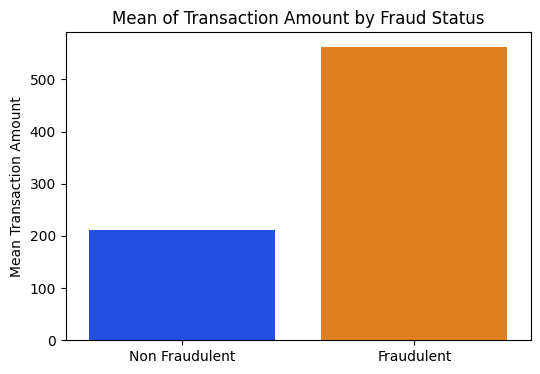

In [ ]:
plt.figure(figsize=(6, 4))  # Ukuran plot
ax = sns.barplot(data=df, x='Is Fraudulent', y='Transaction Amount',hue='Is Fraudulent', palette='bright', estimator='mean',
                 errorbar=None, legend=False) # Barplot mean Transaction Amount berdasarkan status fraud
plt.xticks(ticks=[0, 1], labels=['Non Fraudulent', 'Fraudulent'])  # Label kategori
plt.title('Mean of Transaction Amount by Fraud Status')  # Judul
plt.xlabel('')  # Kosongkan label X (opsional)
plt.ylabel('Mean Transaction Amount')  # Label Y
plt.show()  # Tampilkan plot

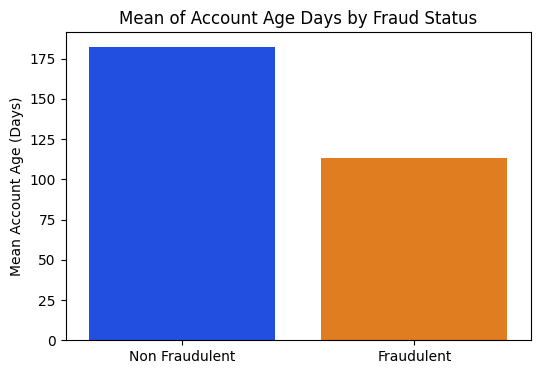

In [ ]:
plt.figure(figsize=(6, 4))  # Ukuran plot
ax = sns.barplot(data=df, x='Is Fraudulent', y='Account Age Days', hue='Is Fraudulent', palette='bright', estimator='mean',
    errorbar=None, legend=False) # Barplot mean Account Age Days berdasarkan status fraud
plt.xticks(ticks=[0, 1], labels=['Non Fraudulent', 'Fraudulent'])  # Label kategori
plt.title('Mean of Account Age Days by Fraud Status')  # Judul
plt.xlabel('')  # Kosongkan label X (opsional)
plt.ylabel('Mean Account Age (Days)')  # Label Y
plt.show()  # Tampilkan plot

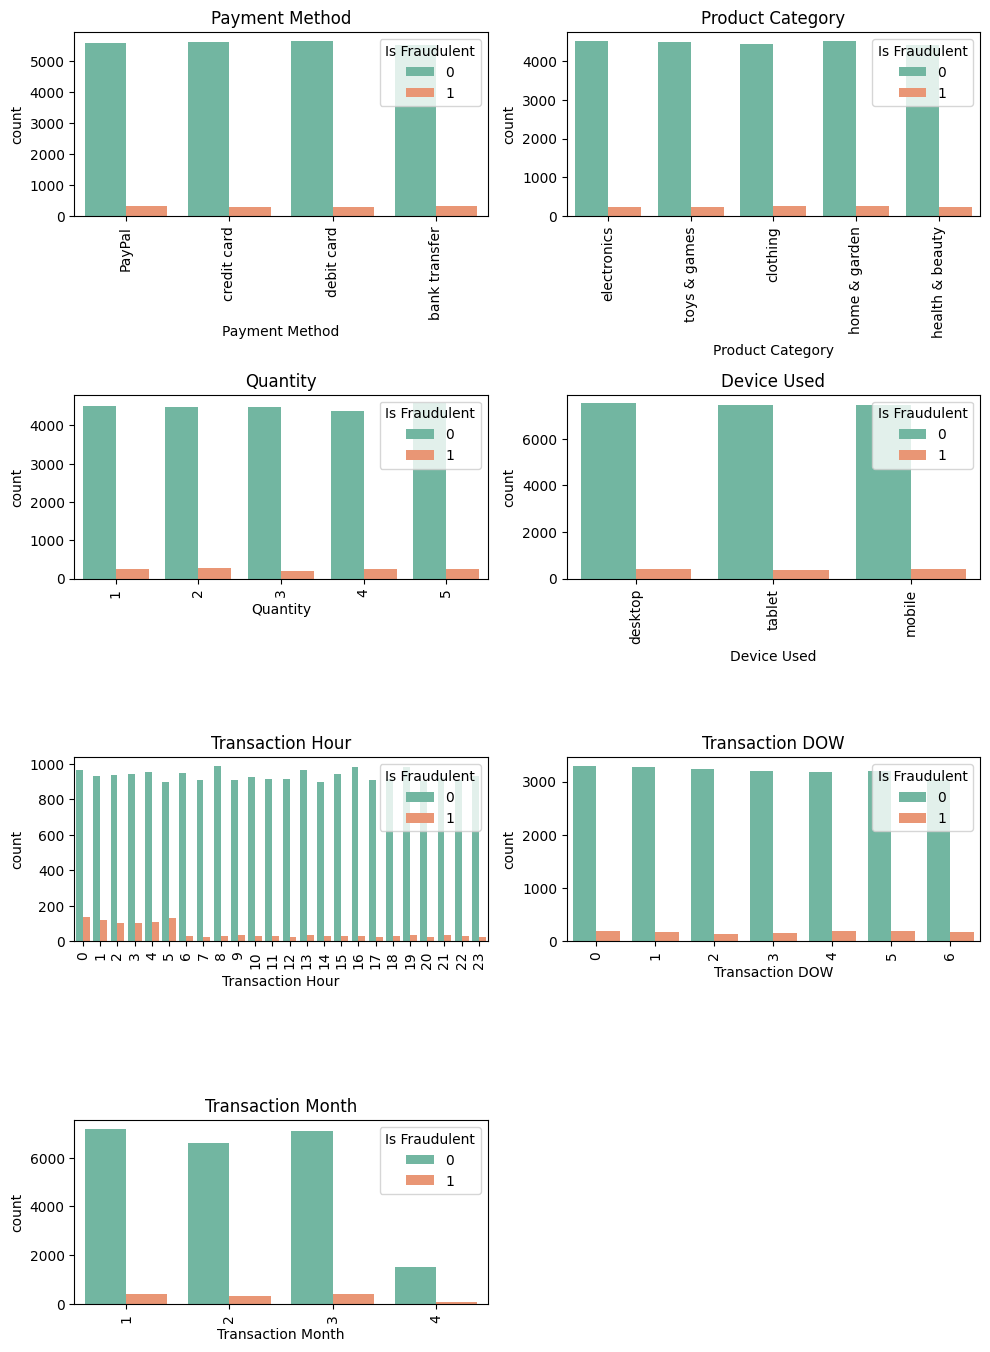

In [ ]:
column = ['Payment Method', 'Product Category',
       'Quantity', 'Device Used', 'Transaction Hour', 'Transaction DOW',
       'Transaction Month']

plt.figure(figsize=(10,35))  # Atur ukuran figure agar tinggi cukup untuk banyak subplot
plot_num = 1  # Inisialisasi nomor subplot mulai dari 1

for col in column:  # Loop untuk setiap kolom di list 'column'
    plt.subplot(10, 2, plot_num)  # Buat subplot grid 10 baris x 2 kolom, posisi ke plot_num
    sns.countplot(data=df, x=col, hue="Is Fraudulent")  # Plot countplot dengan x = kolom dan pemisah warna berdasarkan 'Is Fraudulent'
    plt.xticks(rotation=90)  # Putar label sumbu-x agar tidak tumpang tindih
    plt.title(col)  # Judul plot sesuai nama kolom
    plt.tight_layout()  # Atur layout supaya subplot tidak tumpang tindih
    plot_num += 1  # Naikkan nomor subplot untuk iterasi berikutnya

Visualisasi-visualisasi diatas ini kurang memberikan informasi yang cukup karena jumlah transaksi fraud jauh lebih kecil dibanding transaksi non-fraud. Namun, kita masih bisa cukup mengidentifikasi profil pelanggan yang lebih berpotensi melakukan transaksi fraud.
- Pertama, dari plot terlihat bahwa `transaksi dengan nilai rata-rata di atas 220 dolar cenderung lebih sering dikategorikan sebagai fraud`
- Kemudian, `jika usia akun rata-rata kurang dari 125 hari, kemungkinan transaksi tersebut fraud juga lebih tinggi`
- Terakhir, `transaksi fraud paling banyak terjadi pada jam 0 sampai jam 5 pagi`

## MODELING

In [ ]:
# Melakukan encoding untuk fitur kategorikal dengan .map()

# Payment Method
df['Payment Method'] = df['Payment Method'].map({
    "debit card": 0,
    "credit card": 1,
    "PayPal": 2,
    "bank transfer": 3
})

# Product Category
df['Product Category'] = df['Product Category'].map({
    "home & garden": 0,
    "electronics": 1,
    "toys & games": 2,
    "clothing": 3,
    "health & beauty": 4
})

# Device Used
df['Device Used'] = df['Device Used'].map({
    "desktop": 0,
    "mobile": 1,
    "tablet": 2
})

In [ ]:
# Memisahkan fitur fitur dan target
X = df.drop(columns=['Is Fraudulent'])  # Semua kolom kecuali target
y = df['Is Fraudulent']  # Kolom target

In [ ]:
# Membagi data menjadi train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Mengecek ukuran data
print(f'Ukuran training set: {X_train.shape[0]} samples')
print(f'Ukuran testing set: {X_test.shape[0]} samples')

Ukuran training set: 18907 samples
Ukuran testing set: 4727 samples


In [ ]:
# Menyeimbangkan data training dengan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Cek distribusi kelas setelah SMOTE
print('Distribusi kelas setelah SMOTE:')
print(y_train_smote.value_counts())

# Garis pemisah
print('-' * 50)

# Menampilkan jumlah data train dan test setelah SMOTE
print(f'Jumlah data train setelah SMOTE: {X_train_smote.shape[0]} samples')  # Total train setelah SMOTE
print(f'Jumlah data test (tetap): {X_test.shape[0]} samples')  # Test set tidak diubah oleh SMOTE

Distribusi kelas setelah SMOTE:
Is Fraudulent
0    17929
1    17929
Name: count, dtype: int64
--------------------------------------------------
Jumlah data train setelah SMOTE: 35858 samples
Jumlah data test (tetap): 4727 samples


In [ ]:
# Menstandarisasi fitur dengan StandardScaler
scaler = StandardScaler()

# Fit dan transform hanya pada data train SMOTE
X_train_scaled = scaler.fit_transform(X_train_smote)

# Transform data test (menggunakan scaler dari data train)
X_test_scaled = scaler.transform(X_test)

Random Forest Classifier
Accuracy: 0.8343558282208589
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      4483
           1       0.18      0.61      0.28       244

    accuracy                           0.83      4727
   macro avg       0.58      0.73      0.59      4727
weighted avg       0.93      0.83      0.87      4727



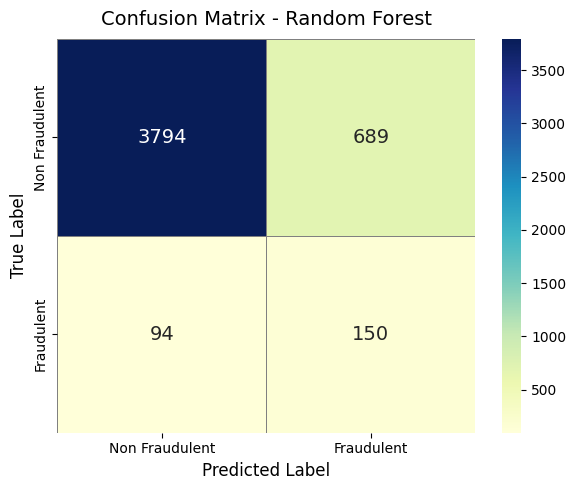

In [ ]:
# Inisialisasi model Random Forest
rf = RandomForestClassifier(
    n_estimators=300,        # jumlah pohon, default 100, bisa ditambah supaya model lebih stabil
    max_depth=3,            # batasi kedalaman pohon supaya tidak overfit
    min_samples_split=2,     # minimal sampel di node sebelum dipisah, default 2,
    min_samples_leaf=3,      # minimal sampel di daun pohon
    max_features='sqrt',     # jumlah fitur yg dicoba tiap split, 'sqrt' umum dipakai buat klasifikasi
    random_state=42,
    n_jobs=-1                # pakai semua core CPU supaya training lebih cepat
)

# Melatih model dengan data training yang sudah diseimbangkan dan distandarisasi
rf.fit(X_train_scaled, y_train_smote)

# Memprediksi data uji (juga sudah distandarisasi)
y_pred = rf.predict(X_test_scaled)

# Menampilkan hasil evaluasi
print('Random Forest Classifier')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, linecolor='gray',
            xticklabels=['Non Fraudulent', 'Fraudulent'],
            yticklabels=['Non Fraudulent', 'Fraudulent'],
            annot_kws={"size": 14})  # Ukuran angka dalam kotak

# Judul dan label
plt.title('Confusion Matrix - Random Forest', fontsize=14, pad=10)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Layout rapih
plt.tight_layout()
plt.show()

## ✅ Kesimpulan Model Random Forest
🔍 **Evaluasi Akurasi dan Classification Report**

* ✅ **Akurasi keseluruhan model sebesar 85%**
  Artinya, dari seluruh data uji yang diuji, 90% prediksi model sesuai dengan label aslinya.

* 🟩 **Kinerja untuk kelas *Non Fraudulent (0)*:**

  * **Precision: 98%** → Dari semua transaksi yang diprediksi model sebagai *non fraud*, 98% benar-benar merupakan *non-fraud*.
  * **Recall: 85%** → Dari semua transaksi yang benar-benar *non fraud*, 85% berhasil dikenali oleh model dengan benar.
  * **F1-Score: 92%** → Kombinasi precision dan recall menunjukkan performa yang kuat untuk kelas mayoritas.

* 🟥 **Kinerja untuk kelas *Fraudulent (1)*:**

  * **Precision: 18%** → Dari semua transaksi yang di prediksi model sebagai *fraud*, sekitar 18% memang benar merupakan penipuan. Ini menunjukkan banyak false positive (prediksi fraud tapi sebenarnya bukan).
  * **Recall: 61%** → Model berhasil menangkap lebih dari setengah dari transaksi fraud yang sebenarnya terjadi. `Ini penting, karena fokus utama deteksi fraud adalah menangkap sebanyak mungkin fraud yang nyata.`

    Dalam kasus deteksi penipuan (fraud detection), recall lebih penting daripada precision karena:
    - `Recall tinggi berarti model mampu menangkap sebagian besar transaksi fraud yang sebenarnya terjadi`, sehingga meminimalkan risiko fraud lolos tanpa terdeteksi yang berpotensi menyebabkan kerugian finansial besar.
    - `Meskipun precision rendah berarti banyak false positive, hal ini masih lebih dapat ditoleransi daripada kehilangan fraud sebenarnya`. False positive bisa ditindaklanjuti dengan verifikasi manual, sedangkan false negative (fraud yang tidak terdeteksi) dapat berakibat fatal.
    - Jadi, model dengan recall tinggi membantu memaksimalkan deteksi fraud, menjadikan sistem lebih aman dan efektif dalam pencegahan penipuan.

  * **F1-Score: 28%** → Kombinasi precision dan recall masih rendah, tapi nilai recall yang lebih tinggi menjadi indikasi model mulai mengenali pola fraud.

* ⚖️ **Macro Average (rata-rata antar kelas):**

  * Memberikan gambaran menyeluruh atas performa model tanpa dipengaruhi oleh jumlah data yang tidak seimbang antar kelas.
  * Nilai F1: **59%**, artinya performa model sedang dalam tahap berkembang terutama untuk kelas minoritas (fraud).

* 📊 **Weighted Average:**

  * Karena mempertimbangkan jumlah data tiap kelas, nilai ini memberi gambaran realistis terhadap performa keseluruhan model.
  * Nilai F1 sebesar 87% mencerminkan kekuatan model dalam mengenali transaksi mayoritas.


**📊 Evaluasi Confusion Matrix:**
Berdasarkan confusion matrix dari model Random Forest, berikut adalah analisis dan kesimpulan:
- True Negative (TN): `3794` — `Non-Fraudulent yang diprediksi benar`
- False Positive (FP): `689` — `Non-Fraudulent yang salah diklasifikasikan sebagai Fraudulent`
- False Negative (FN): `94` — `Fraudulent yang salah diklasifikasikan sebagai Non-Fraudulent`
- True Positive (TP): `150` — `Fraudulent yang diprediksi benar`

## FUNGSI DETEKSI FRAUD DARI INPUT MANUAL

In [ ]:
def predict_fraud(transaction_amount, payment_method, product_category,
                  quantity, customer_age, device_used, account_age_days,
                  transaction_hour, transaction_day, transaction_dow, transaction_month):
    """
    Fungsi ini menerima input transaksi dan memprediksi apakah transaksi tersebut fraud atau tidak.
    """

    # Mapping fitur kategorikal
    payment_map = {"debit card": 0, "credit card": 1, "PayPal": 2, "bank transfer": 3}
    category_map = {"home & garden": 0, "electronics": 1, "toys & games": 2, "clothing": 3, "health & beauty": 4}
    device_map = {"desktop": 0, "mobile": 1, "tablet": 2}

    # Konversi input ke bentuk array numerik
    input_data = np.array([[
        transaction_amount,
        payment_map.get(payment_method, -1),
        category_map.get(product_category, -1),
        quantity,
        customer_age,
        device_map.get(device_used, -1),
        account_age_days,
        transaction_hour,
        transaction_day,
        transaction_dow,
        transaction_month
    ]])

    # Validasi input
    if (input_data < 0).any():
        print("❌ Input mengandung nilai tidak valid! Periksa kembali kategori yang dimasukkan.")
        return

    # Scaling input sesuai scaler training
    input_scaled = scaler.transform(input_data)

    # Prediksi dan probabilitas
    prediction = rf.predict(input_scaled)[0]
    probability = rf.predict_proba(input_scaled)[0][prediction]

    # Output hasil prediksi
    if prediction == 1:
        print(f"⚠️ Transaksi diprediksi FRAUDULENT (probabilitas: {probability:.2%})")
    else:
        print(f"✅ Transaksi diprediksi NON-FRAUDULENT (probabilitas: {probability:.2%})")

predict_fraud(
    transaction_amount=750,
    payment_method="PayPal",
    product_category="electronics",
    quantity=20,
    customer_age=45,
    device_used="desktop",
    account_age_days=25,
    transaction_hour=5,
    transaction_day=15,
    transaction_dow=2,
    transaction_month=3
)

predict_fraud(
    transaction_amount=320,
    payment_method="bank transfer",
    product_category="health & beauty",
    quantity=2,
    customer_age=18,
    device_used="desktop",
    account_age_days=365,
    transaction_hour=2,
    transaction_day=15,
    transaction_dow=2,
    transaction_month=3
)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


⚠️ Transaksi diprediksi FRAUDULENT (probabilitas: 64.83%)
✅ Transaksi diprediksi NON-FRAUDULENT (probabilitas: 62.29%)
